In [2]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices,
                generate_cascading_receptors,
                generate_targeted_receptors,
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap)
from run import initialize,train,test

In [42]:
n_units=3
k_sub = 5
n_families = 4
N_train = 2**16
N_test = 2**14
CONF = {
        "n_units": n_units,
        "n_families": n_families,
        "latent_dim": 3,
        "k_sub": k_sub,
        "batch_size": N_train,
        "epochs": 5000,
        "lr": 0.05,
        "cov_weight":1.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)],dtype=torch.long), # size must be smaller or equal to n_units
        "init_means":[np.random.randint(1,8) for _ in range(n_families)], # size must be n_families
        "shape_sigma": 0.5,
        "tolerant":False, # set whether we want tolerance for heteromers on the covariance loss
        "optimizer":"Adam",
        "momentum":0.9,
        "exact_loss":False,
        "temperature":0.1
    }

Fitting UMAP... (This may take a few seconds)


(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'UMAP Projection of 3D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

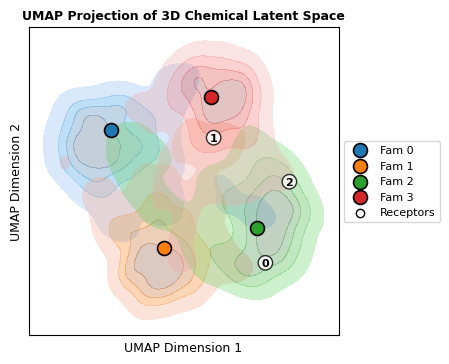

In [20]:
env,rec,loss_fn,optimize = initialize(CONF,SymmetricEnv=True)
plot_latent_umap(env,CONF["receptor_indices"])

In [21]:
stat = train(CONF,env,rec,loss_fn,optimize)
ent_test = test(CONF,env,rec,loss_fn,optimize,N_samples=N_test,indices = CONF['receptor_indices'])

Training for 5000 epochs...


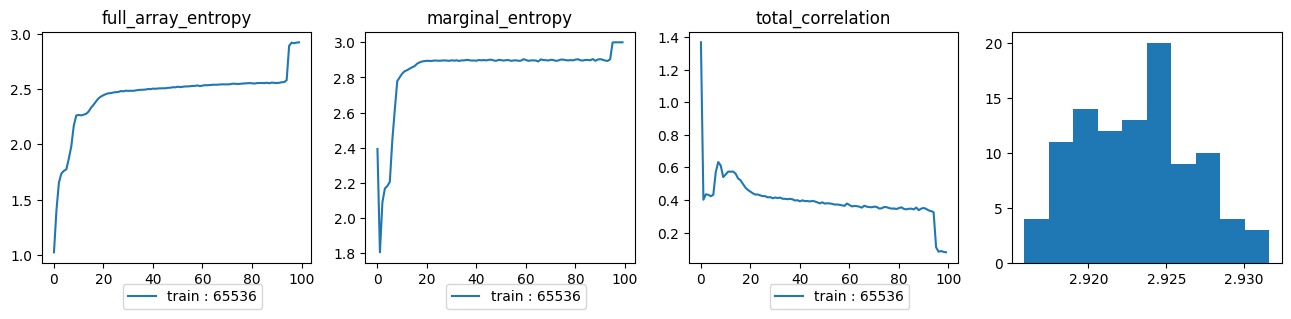

In [22]:
fig,ax = plt.subplots(ncols=4,figsize=(4*4,3))
for i,key in enumerate(stat.keys()):
    ax[i].plot(stat[key],label=f'train : {N_train}')
    ax[i].set_title(key)

ax[3].hist(ent_test)

for i in range(3):
    ax[i].legend(loc=(0.3,-.2))
#ax[2].set_ylim(0.1,0.6)

In [43]:
#CONF['receptor_indices'] = torch.tensor([[0,0,0,0,0],[1,1,1,1,1],[2,2,2,2,2],[0,0,1,1,1]],dtype=torch.long)
CONF['receptor_indices'] = generate_cascading_receptors(n_units=CONF['n_units'], k_sub=CONF['k_sub'], n_sensors=11)
#CONF['epochs'] = 5 * 10**4
print(CONF['receptor_indices'])

tensor([[1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2],
        [0, 0, 0, 0, 0],
        [1, 1, 1, 2, 2],
        [0, 1, 1, 1, 1],
        [1, 1, 2, 2, 2],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 1, 1],
        [0, 2, 2, 2, 2],
        [0, 0, 0, 0, 2],
        [0, 0, 2, 2, 2]])


Fitting UMAP... (This may take a few seconds)
Fitting UMAP... (This may take a few seconds)


(<Figure size 800x400 with 2 Axes>,
 <Axes: title={'center': 'UMAP Projection of 3D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

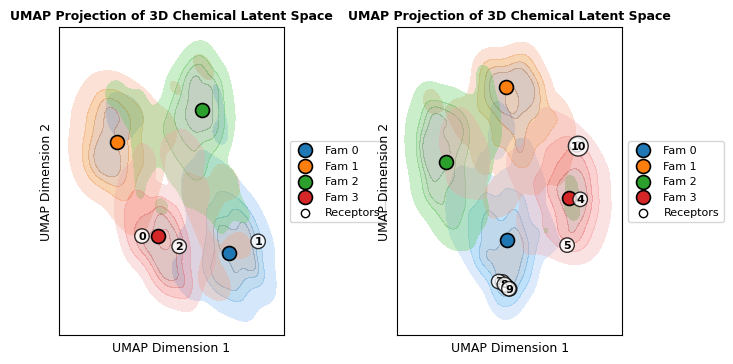

In [37]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
plot_latent_umap(env, torch.tensor([[0,0,0,0,0],[1,1,1,1,1],[2,2,2,2,2]]),ax=ax[0])
plot_latent_umap(env,CONF["receptor_indices"],ax=ax[1])

In [44]:
ent_test_hetero = test(CONF,env,rec,loss_fn,optimize,N_samples=N_test,indices = CONF['receptor_indices'])

In [45]:
env,rec,loss_fn,optimize = initialize(CONF,SymmetricEnv=True)
CONF['epochs'] = 5*10**3
stat = train(CONF,env,rec,loss_fn,optimize)
ent_test_het_opt_het = test(CONF,env,rec,loss_fn,optimize,N_samples=N_test,indices = CONF['receptor_indices'])

Training for 5000 epochs...


In [40]:
print(f"entropy of optimized homomers : {np.mean(ent_test,axis=0):.2f}")
print(f"entropy of optimized homomers + heteromers : {np.mean(ent_test_hetero,axis=0)}")
print(f"entropy of optimized heteromers : {np.mean(ent_test_het_opt_het,axis=0)}")

entropy of optimized homomers : 2.92
entropy of optimized homomers + heteromers : 4.145848183631897
entropy of optimized heteromers : 8.30403339439556e-05


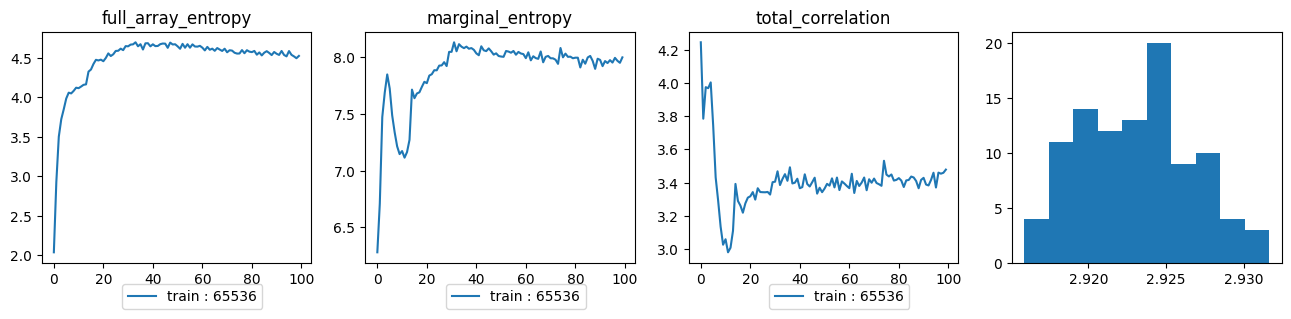

In [46]:
fig,ax = plt.subplots(ncols=4,figsize=(4*4,3))
for i,key in enumerate(stat.keys()):
    ax[i].plot(stat[key],label=f'train : {N_train}')
    ax[i].set_title(key)

ax[3].hist(ent_test)

for i in range(3):
    ax[i].legend(loc=(0.3,-.2))
    #ax[i].set_xscale('log')
#ax[2].set_ylim(0.1,0.6)

Fitting UMAP... (This may take a few seconds)
Fitting UMAP... (This may take a few seconds)


(<Figure size 800x400 with 2 Axes>,
 <Axes: title={'center': 'UMAP Projection of 3D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

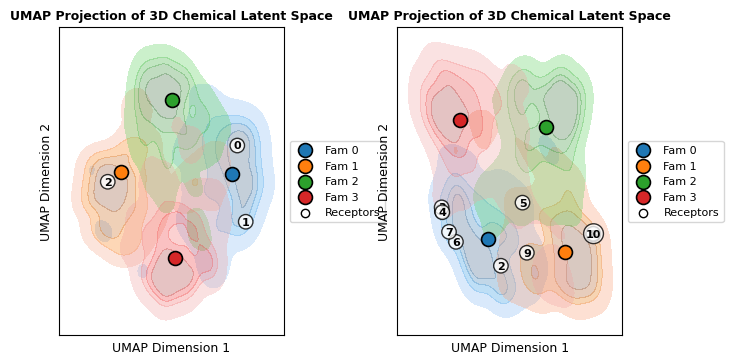

In [47]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
plot_latent_umap(env, torch.tensor([[0,0,0,0,0],[1,1,1,1,1],[2,2,2,2,2]]),ax=ax[0])
plot_latent_umap(env,CONF["receptor_indices"],ax=ax[1])